[PySM 3.4.6](https://github.com/galsci/pysm/releases/tag/3.4.6) is out! Install it from [PyPI](https://pypi.org/project/pysm3/3.4.6/) or conda-forge:

    pip install --upgrade pysm3==3.4.6

This release adds two lensed kinetic Sunyaev–Zeldovich (kSZ) presets based on the [FLAMINGO simulations](https://doi.org/10.1093/mnras/stag625), and documents the cosmological parameters used by the long-standing `c1` CMB model. This notebook shows how to use the new presets with the standard PySM API.

In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pysm3
from IPython.display import Markdown, display
from pysm3 import units as u

## New FLAMINGO kSZ presets

PySM 3.4.6 adds two models that can be selected through `preset_strings`:

- `ksz5`: the fiducial FLAMINGO `L1_m9` feedback model
- `ksz6`: the strongest-feedback `fgas-8sigma` model

Both are lensed, full-sky HEALPix templates at native NSIDE 4096. The following summary identifies the model and template used by each preset.

In [2]:
models = {
    "ksz5": ("Fiducial L1_m9", "flamingo/ksz/L1_m9_lensed_kSZ_uKCMB.fits"),
    "ksz6": ("Strong feedback (fgas-8sigma)",
             "flamingo/ksz/fgas-8sigma_lensed_kSZ_uKCMB.fits"),
}
rows = ["| preset | FLAMINGO model | native NSIDE | template |",
        "|---|---|---:|---|"]
for name, (label, template) in models.items():
    rows.append(f"| `{name}` | {label} | 4096 | `{template}` |")
display(Markdown("\n".join(rows)))

| preset | FLAMINGO model | native NSIDE | template |
|---|---|---:|---|
| `ksz5` | Fiducial L1_m9 | 4096 | `flamingo/ksz/L1_m9_lensed_kSZ_uKCMB.fits` |
| `ksz6` | Strong feedback (fgas-8sigma) | 4096 | `flamingo/ksz/fgas-8sigma_lensed_kSZ_uKCMB.fits` |

## Generate and compare the kSZ maps with PySM

The workflow is the same as for every other PySM preset: create a `Sky`, call `get_emission`, and work with the returned map. The example below compares the new FLAMINGO models with the existing WebSky and AGORA kSZ presets at 143 GHz. The embedded result was generated at NSIDE 2048 with this code in the [release validation notebook](https://github.com/galsci/pysm/blob/3.4.6/docs/preprocess-templates/verify_templates/compare_flamingo_ksz.ipynb).

The full comparison downloads 9.75 GiB into the Astropy cache. Run it on a compute node with at least 15 GiB of free persistent shared storage and 32 GiB of RAM; PySM temporarily uses additional memory while downgrading the native NSIDE 8192 AGORA maps in double precision. To try only `ksz5` and `ksz6`, set `presets = ["ksz5", "ksz6"]`: those templates occupy 3.00 GiB, so allow 4 GiB of free cache space and 16 GiB of RAM.

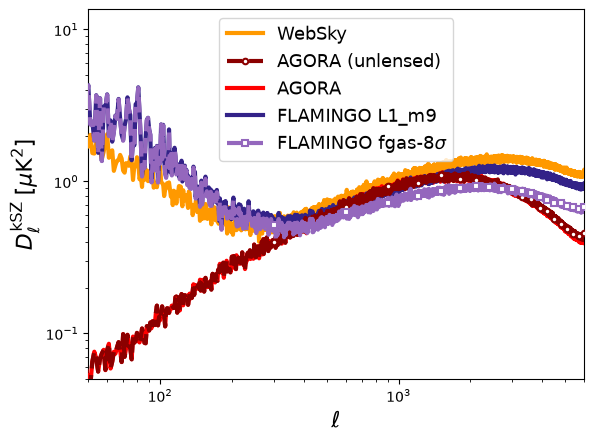

In [3]:
presets = ["ksz1", "ksz2", "ksz3", "ksz5", "ksz6"]
titles = {
    "ksz1": "WebSky",
    "ksz2": "AGORA (unlensed)",
    "ksz3": "AGORA",
    "ksz5": "FLAMINGO L1_m9",
    "ksz6": r"FLAMINGO fgas-$8\sigma$",
}
colors = {"ksz1": "#ff9900", "ksz2": "#8b0000",
          "ksz3": "#ff0000", "ksz5": "#332288",
          "ksz6": "#9467bd"}
styles = {"ksz1": "-", "ksz2": "--", "ksz3": "-",
          "ksz5": "-", "ksz6": "--"}
markers = {"ksz2": "o", "ksz6": "s"}

lmax = 6000
spectra = {}
for preset in presets:
    sky = pysm3.Sky(
        nside=2048, preset_strings=[preset], output_unit=u.uK_CMB
    )
    intensity = sky.get_emission(143 * u.GHz)[0].copy()
    spectra[preset] = hp.anafast(intensity.value, lmax=lmax)
    del intensity, sky

for preset, cl in spectra.items():
    ell = np.arange(len(cl))
    dl = ell * (ell + 1) * cl / (2 * np.pi)
    plt.loglog(ell, dl, color=colors[preset],
               linestyle=styles[preset], linewidth=3,
               marker=markers.get(preset), markevery=300,
               markersize=4, markerfacecolor="white",
               label=titles[preset])

plt.xlim(50, lmax)
plt.ylim(0.05, None)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell^{\rm kSZ}\;[\mu\mathrm{K}^2]$")
plt.legend()

The two purple curves are the new FLAMINGO models. The `fgas-8sigma` run has stronger baryonic feedback, which distributes gas more broadly and reduces small-scale kSZ power. Users can now evaluate this modeling uncertainty by changing the PySM preset from `ksz5` to `ksz6`.

## Cosmological parameters for the `c1` model

The `c1` preset generates a lensed CMB realization from unlensed CAMB spectra. Version 3.4.6 documents the original CAMB [`params.ini`](https://github.com/galsci/pysm/blob/3.4.6/docs/cmb_c1_params.ini) and compares it with the Planck 2015 TT,TE,EE+lowP best fit. The principal input values are summarized below.

In [4]:
c1_parameters = {
    "ombh2": (r"$\Omega_b h^2$", "0.02225"),
    "omch2": (r"$\Omega_c h^2$", "0.1198"),
    "hubble": (r"$H_0$ [km/s/Mpc]", "70"),
    "re_optical_depth": (r"$\tau$", "0.06"),
    "scalar_spectral_index(1)": (r"$n_s$", "0.9645"),
    "scalar_amp(1)": (r"$A_s$", "2.1e-9"),
    "l_max_scalar": (r"maximum $\ell$", "2200"),
}
rows = ["| CAMB key | meaning | c1 value |", "|---|---|---:|"]
rows += [f"| `{key}` | {meaning} | {value} |"
         for key, (meaning, value) in c1_parameters.items()]
display(Markdown("\n".join(rows)))

| CAMB key | meaning | c1 value |
|---|---|---:|
| `ombh2` | $\Omega_b h^2$ | 0.02225 |
| `omch2` | $\Omega_c h^2$ | 0.1198 |
| `hubble` | $H_0$ [km/s/Mpc] | 70 |
| `re_optical_depth` | $\tau$ | 0.06 |
| `scalar_spectral_index(1)` | $n_s$ | 0.9645 |
| `scalar_amp(1)` | $A_s$ | 2.1e-9 |
| `l_max_scalar` | maximum $\ell$ | 2200 |

The primary density and spectral-index parameters match the documented Planck 2015 values. Some secondary values differ slightly, including `hubble = 70`, `tau = 0.06`, and `A_s = 2.1e-9`; these values are now explicit and can be recorded alongside simulations that use `c1`.

See the [PySM model documentation](https://pysm3.readthedocs.io/en/latest/models.html) for details, and report problems on the [issue tracker](https://github.com/galsci/pysm/issues).